In [1]:
#Install the necessary libraries
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install gradio

In [2]:
#Import necessary libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
import gradio as gr
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


c:\Users\shane\anaconda3\envs\new\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Import all files containing the data
csv_files = glob.glob('*.{}'.format('csv'))
csv_files

['blackpoolNjantojuly24.csv',
 'blackpoolNseptodec23.csv',
 'chesterjantoapril24.csv',
 'chestermaytojuly24.csv',
 'chestersepttodec23.csv',
 'service_metrics2.csv',
 'service_metricstest.csv']

In [4]:
#Create a DataFrame with all data
df = pd.concat([pd.read_csv(f) for f in csv_files ], ignore_index=True)
df

,origin_location,destination_location,gbtt_ptd,gbtt_pta,toc_code,matched_services,rid,date_of_service,location,gbtt_ptd_location,gbtt_pta_location,actual_td_location,actual_ta_location,late_canc_reason
0,LIV,BPN,638,757.0,NT,147,202401018730006,2024-01-01,LIV,638.0,NaN,637.0,NaN,NaN
1,LIV,BPN,638,757.0,NT,147,202401018730006,2024-01-01,HUY,647.0,646.0,646.0,646.0,NaN
2,LIV,BPN,638,757.0,NT,147,202401018730006,2024-01-01,SNH,655.0,654.0,654.0,654.0,NaN
3,LIV,BPN,638,757.0,NT,147,202401018730006,2024-01-01,WGN,709.0,707.0,710.0,708.0,NaN
4,LIV,BPN,638,757.0,NT,147,202401018730006,2024-01-01,EBA,720.0,718.0,719.0,718.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691757,LIV,MAN,2336,37.0,NT,83,202406287132578,2024-06-28,HGN,3.0,3.0,3.0,3.0,NaN
691758,LIV,MAN,2336,37.0,NT,83,202406287132578,2024-06-28,WID,7.0,6.0,7.0,6.0,NaN
691759,LIV,MAN,2336,37.0,NT,83,202406287132578,2024-06-28,WAW,13.0,13.0,15.0,13.0,NaN
691760,LIV,MAN,2336,37.0,NT,83,202406287132578,2024-06-28,WAC,17.0,17.0,18.0,17.0,NaN


In [5]:
#Size of DataFrame
df.shape

(691762, 14)

Data visualisation

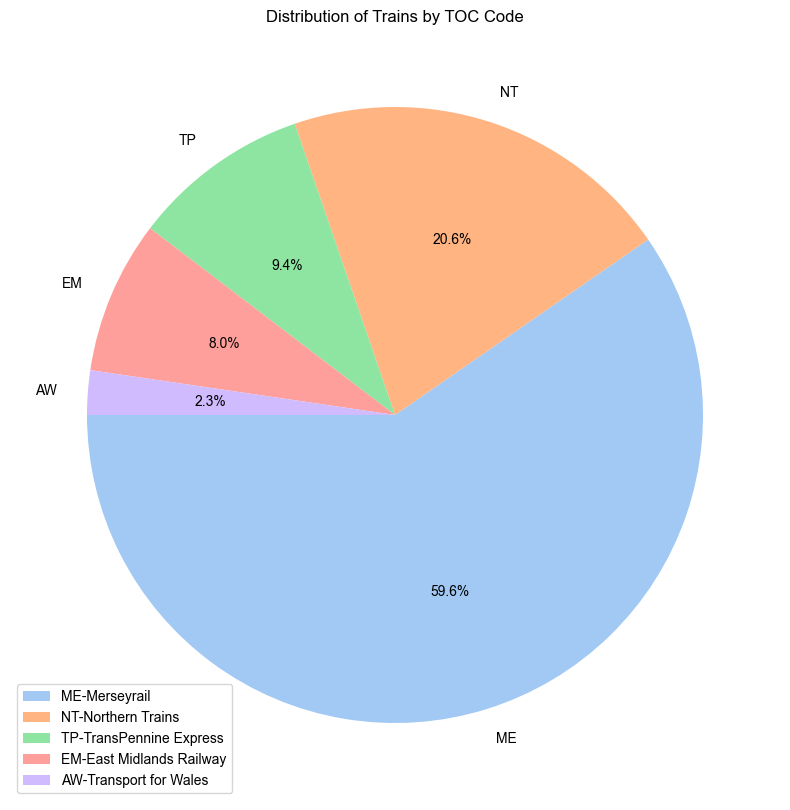

In [6]:
#Count the number of train for each train operating company(TOC)
train_count = df['toc_code'].value_counts()

#Create a pie chart showing distribution of trains by TOC
plt.figure(figsize=(10, 10))
plt.pie(train_count, labels=train_count.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"), startangle=180)
plt.title('Distribution of Trains by TOC Code')
plt.legend(labels = ['ME-Merseyrail','NT-Northern Trains','TP-TransPennine Express','EM-East Midlands Railway','AW-Transport for Wales'], loc = 'lower left')
sns.set(font_scale=1)
plt.show()

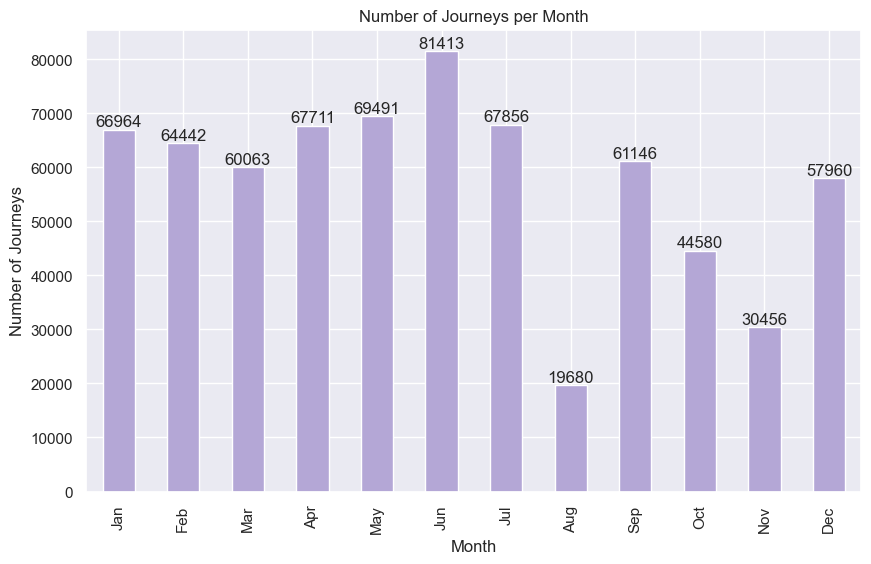

In [7]:
#Convert the 'date_of_service' column to datetime and extract the month
df['date_of_service'] = pd.to_datetime(df['date_of_service'])
df['month'] = df['date_of_service'].dt.month

#Count the number of journeys in each month
journeys_per_month = df.groupby('month').size()

#Create the bar chart showing distribution of journeys by month
plt.figure(figsize=(10, 6))
ax = journeys_per_month.plot(kind='bar', color='#b4a7d6')
plt.title('Number of Journeys per Month')
plt.xlabel('Month')
plt.ylabel('Number of Journeys')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y')
#Annotate each bar with its value
for i, count in enumerate(journeys_per_month):
    ax.text(i, count + 50, str(count), ha='center', va='bottom')
plt.show()


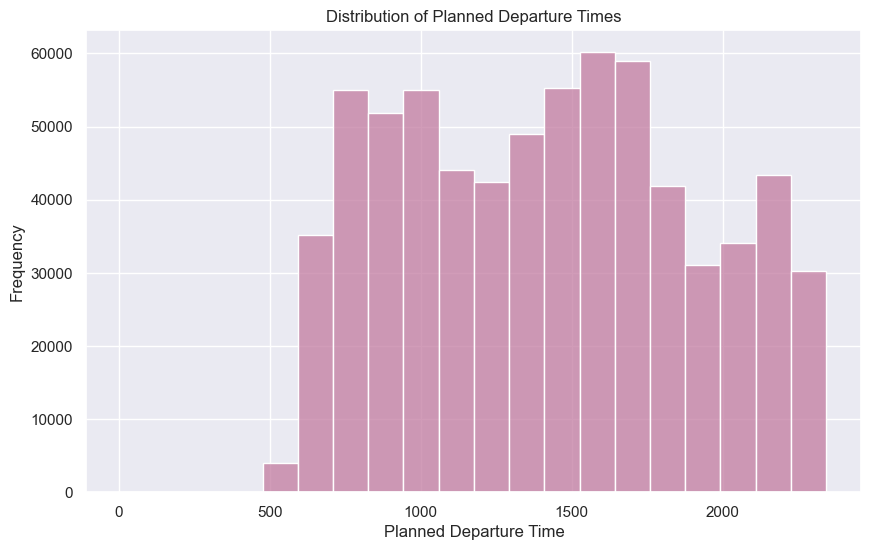

In [8]:
#Create a bar chart displaying the distribution of journeys by hour of the day
plt.figure(figsize=(10, 6))
sns.histplot(df['gbtt_ptd'], bins=20, color='#c27ba0')
sns.set(font_scale=1)
plt.title('Distribution of Planned Departure Times')
plt.xlabel('Planned Departure Time')
plt.ylabel('Frequency')
plt.show()


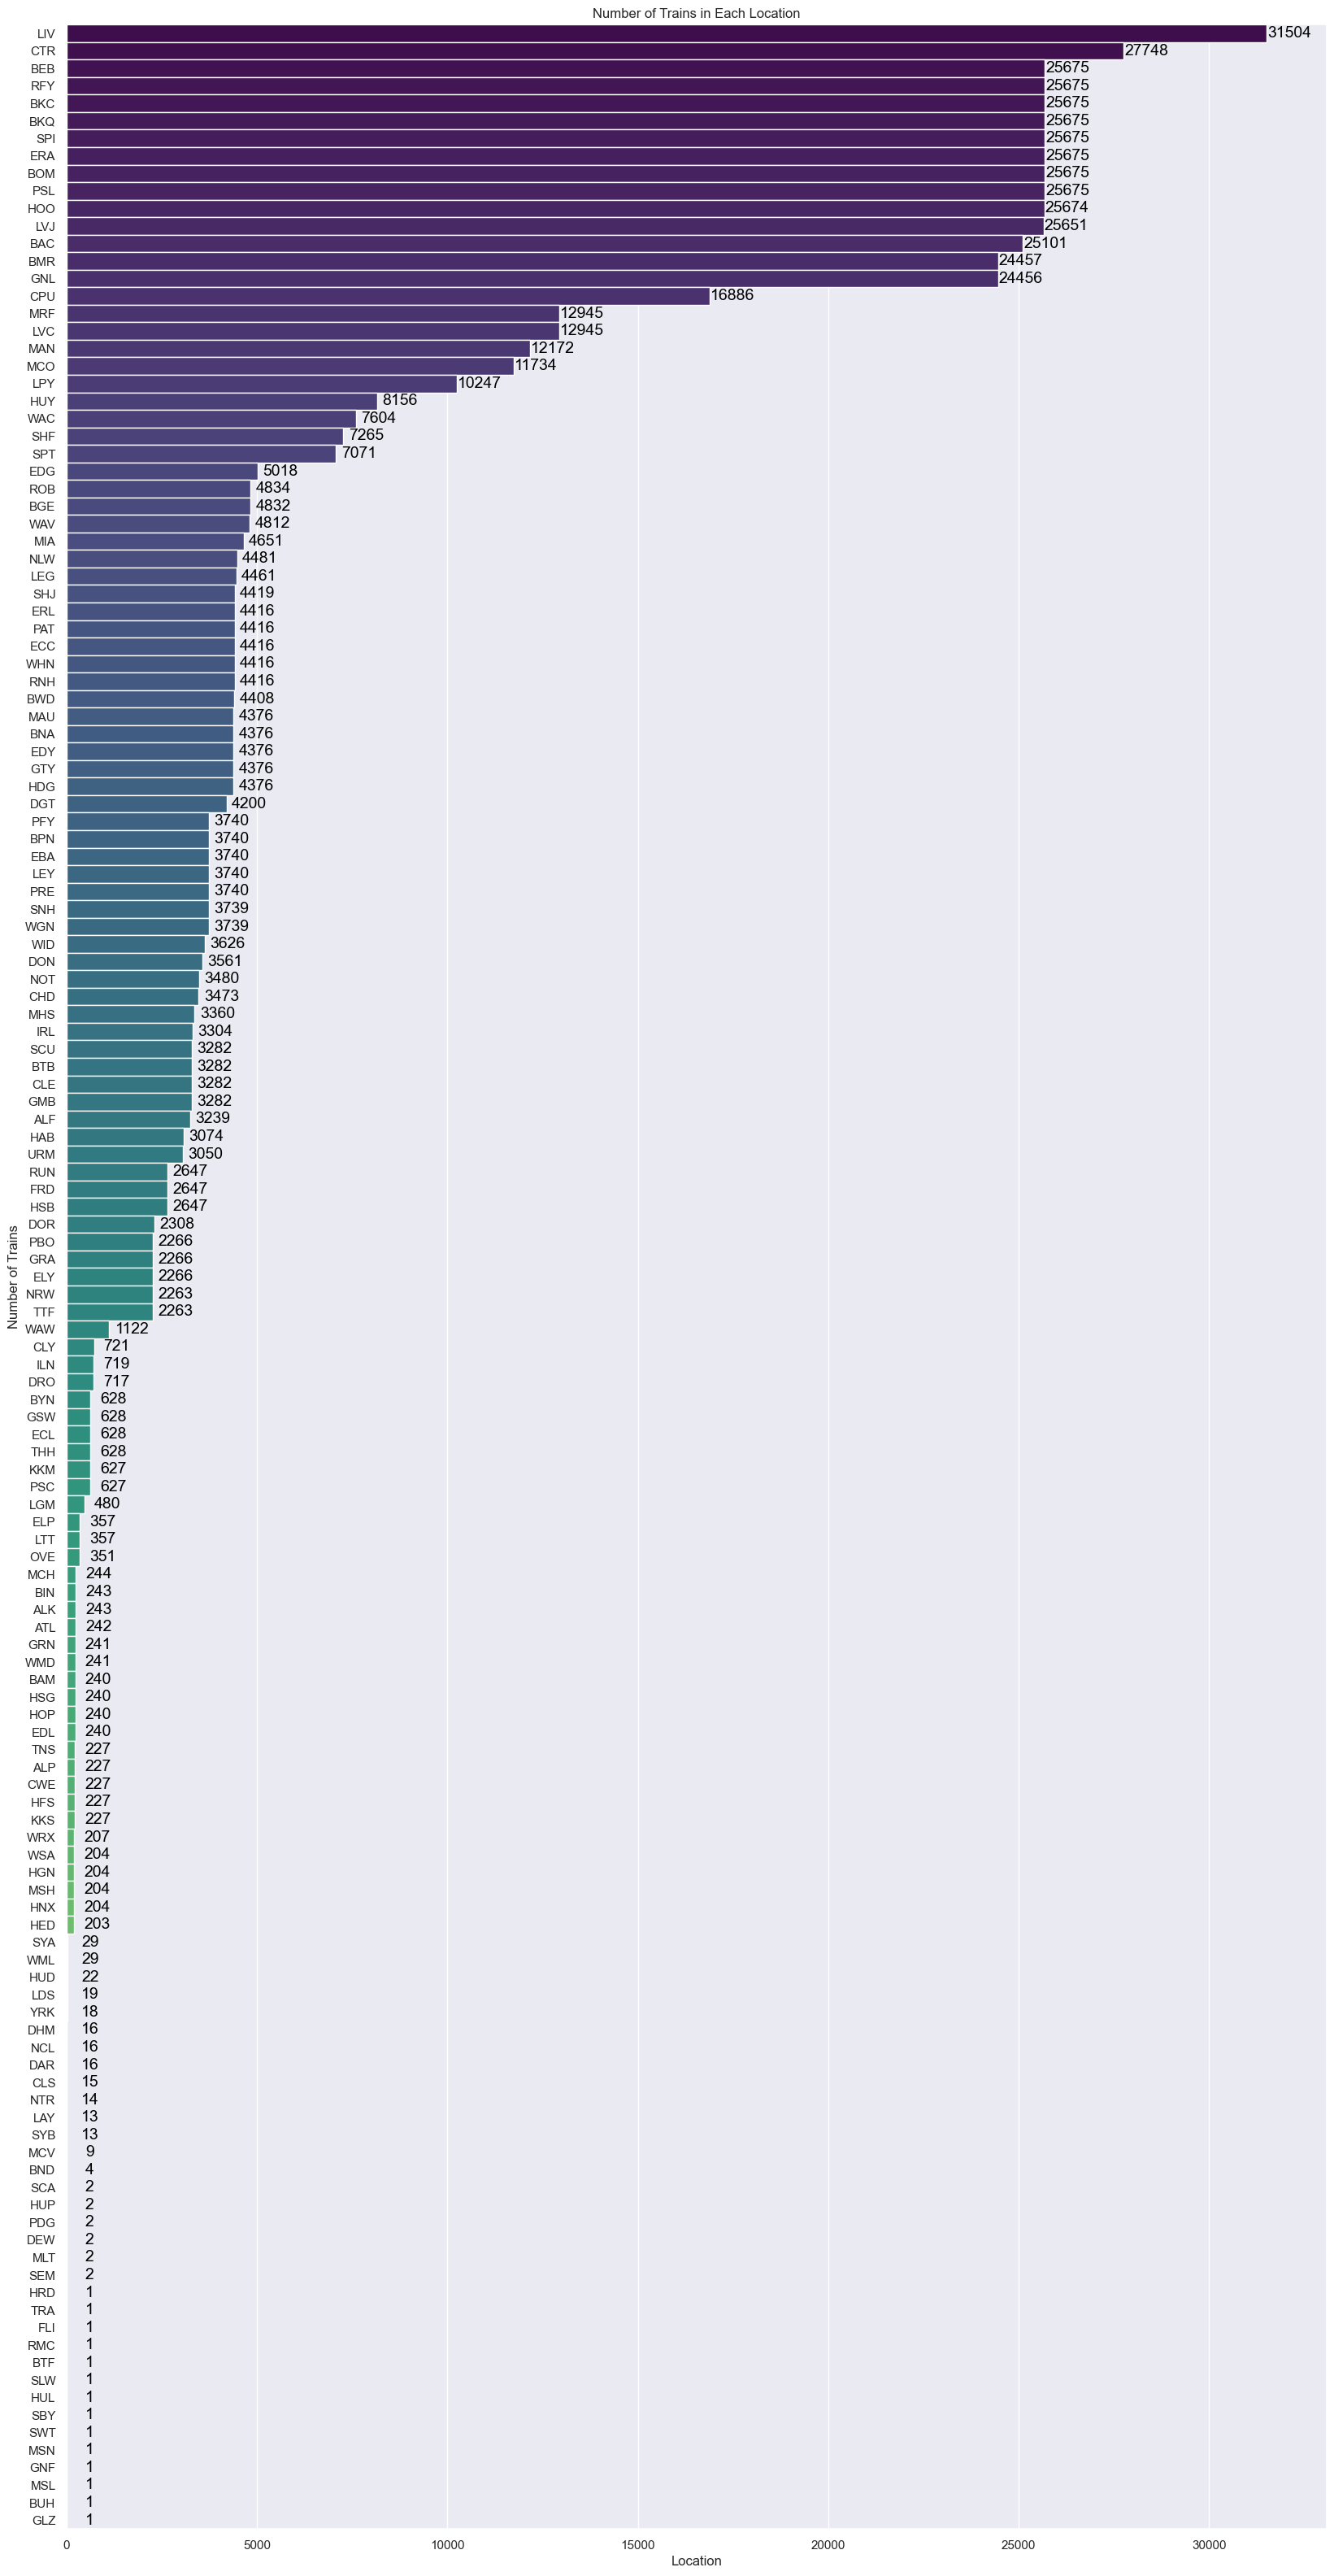

In [9]:
#Count the number of journeys at each location
location_counts = df['location'].value_counts().reset_index()
location_counts.columns = ['location', 'count']

#Create a bar chart showing distribution of train journeys by location
plt.figure(figsize=(20, 40))
sns.set(font_scale=1)
palette = sns.color_palette("viridis", len(location_counts)) 
barplot = sns.barplot(y='location', x='count', data=location_counts,hue='location', palette=palette, width= 1, legend=False )
#Annotate each bar with its value
for bar in barplot.patches:
    bar_width = bar.get_width()
    plt.text(
        bar_width + 600,  
        bar.get_y() + bar.get_height() / 2,  
        f'{int(bar_width)}',  
        ha='center',  
        va='center',  
        fontsize=14,  
        color='black'  
    )
plt.title('Number of Trains in Each Location')
plt.xlabel('Location')
plt.ylabel('Number of Trains')
plt.show()

Data pre-procesing

In [10]:
#Drop rows with cities occuring less number of times
less_cities = ['WML','SYA','HUD','LDS','YRK','DHM','NCL','DAR','CLS','NTR','LAY','SYB','MCV','BND','PDG','HUP','SEM','DEW','SCA','MLT','SLW','SBY','HUL','BUH','GNF','MSL','SWT','MSN','RMC','BTF','FLI','TRA','HRD','GLZ']
for x in less_cities:
    df = df.drop(df[df['location'] == x].index)


In [11]:
#Drop rows with location as LIV and CTR and no arrival time
df = df[~((df['location'] == 'LIV') & (df['gbtt_pta_location'].isna()))]
df = df[~((df['location'] == 'CTR') & (df['gbtt_pta_location'].isna()))]


In [12]:
#Number of NaN values in each column
nan_count_per_column = df.isna().sum()
print(nan_count_per_column)


origin_location              0
destination_location         0
gbtt_ptd                     0
gbtt_pta                   262
toc_code                     0
matched_services             0
rid                          0
date_of_service              0
location                     0
gbtt_ptd_location        32539
gbtt_pta_location         1539
actual_td_location       82390
actual_ta_location       53321
late_canc_reason        569488
month                        0
dtype: int64


In [13]:
#Handle missing values by doing a backward fill or assigning default values
df.fillna({
    'gbtt_pta': df['gbtt_pta'].bfill(),
    'gbtt_pta_location': df['gbtt_pta_location'].bfill(),
    'actual_ta_location': df['actual_ta_location'].bfill(),
    'gbtt_ptd_location': df['gbtt_ptd_location'].bfill(),
    'actual_td_location': df['actual_td_location'].bfill(),
    'late_canc_reason': 'No reason'
}, inplace=True)

#Drop any other missing values
df.dropna(inplace = True)

In [14]:
#Number of NaN values in each column
nan_count_per_column = df.isna().sum()
print(nan_count_per_column)

origin_location         0
destination_location    0
gbtt_ptd                0
gbtt_pta                0
toc_code                0
matched_services        0
rid                     0
date_of_service         0
location                0
gbtt_ptd_location       0
gbtt_pta_location       0
actual_td_location      0
actual_ta_location      0
late_canc_reason        0
month                   0
dtype: int64


In [15]:
#Check for duplicate rows
duplicate_rows = df[df.duplicated()]
print("Duplicate Rows:\n", duplicate_rows)


Duplicate Rows:
 Empty DataFrame
Columns: [origin_location, destination_location, gbtt_ptd, gbtt_pta, toc_code, matched_services, rid, date_of_service, location, gbtt_ptd_location, gbtt_pta_location, actual_td_location, actual_ta_location, late_canc_reason, month]
Index: []


In [16]:
#Get the list of locations to use for Gradio
cities = df['location'].unique()
cities.sort()

In [18]:
# List of tuples with full names and station codes
cities_list = [(' ', ' '),('Alfreton (ALF)', 'ALF'), ('Aslockton (ALK)', 'ALK'), ('Althorpe (ALP)', 'ALP'), ('Attleborough (ATL)', 'ATL'), ('Bache (BAC)', 'BAC'), ('Bamford (BAM)', 'BAM'),
    ('Bebington (BEB)', 'BEB'), ('Broad Green (BGE)', 'BGE'), ('Bingham (BIN)', 'BIN'), ('Birkenhead Central (BKC)', 'BKC'), ('Birkenhead Hamilton Square (BKQ)', 'BKQ'),
    ('Bromborough Rake (BMR)', 'BMR'), ('Burnage (BNA)', 'BNA'), ('Bromborough (BOM)', 'BOM'), ('Blackpool North (BPN)', 'BPN'), ('Barnetby (BTB)', 'BTB'), ('Birchwood (BWD)', 'BWD'),
    ('Bryn (BYN)', 'BYN'), ('Chesterfield (CHD)', 'CHD'), ('Cleethorpes (CLE)', 'CLE'), ('Clydebank (CLY)', 'CLY'), ('Capenhurst (CPU)', 'CPU'), ('Chester (CTR)', 'CTR'),
    ('Crowle (CWE)', 'CWE'), ('Deansgate (DGT)', 'DGT'), ('Doncaster (DON)', 'DON'), ('Dore & Totley (DOR)', 'DOR'), ('Dronfield (DRO)', 'DRO'), ('Euxton Balshaw Lane (EBA)', 'EBA'),
    ('Eccles (ECC)', 'ECC'), ('Eccleston Park (ECL)', 'ECL'), ('Edge Hill (EDG)', 'EDG'), ('Edale (EDL)', 'EDL'), ('East Didsbury (EDY)', 'EDY'), ('Ellesmere Port (ELP)', 'ELP'),
    ('Ely (ELY)', 'ELY'), ('Eastham Rake (ERA)', 'ERA'), ('Earlestown (ERL)', 'ERL'), ('Frodsham (FRD)', 'FRD'), ('Grimsby Town (GMB)', 'GMB'), ('Green Lane (GNL)', 'GNL'),
    ('Grantham (GRA)', 'GRA'), ('Grindleford (GRN)', 'GRN'), ('Garswood (GSW)', 'GSW'), ('Gatley (GTY)', 'GTY'), ('Habrough (HAB)', 'HAB'), ('Heald Green (HDG)', 'HDG'), ('Halewood (HED)', 'HED'),
    ('Hatfield and Stainforth (HFS)', 'HFS'), ('Hough Green (HGN)', 'HGN'), ('Hunts Cross (HNX)', 'HNX'), ('Hook (HOO)', 'HOO'), ('Hope (Derbyshire) (HOP)', 'HOP'), ('Hassocks (HSB)', 'HSB'),
    ('Helsby (HSG)', 'HSG'), ('Huyton (HUY)', 'HUY'), ('Ilkeston (ILN)', 'ILN'), ('Irlam (IRL)', 'IRL'), ('Kirkham and Wesham (KKM)', 'KKM'), ('Kirk Sandall (KKS)', 'KKS'),
    ('Lea Green (LEG)', 'LEG'), ('Leyland (LEY)', 'LEY'), ('Langley Mill (LGM)', 'LGM'), ('Liverpool South Parkway (LPY)', 'LPY'), ('Little Sutton (LTT)', 'LTT'),
    ('Liverpool Central (LVC)', 'LVC'), ('Liverpool James Street (LVJ)', 'LVJ'), ('Manchester Piccadilly (MAN)', 'MAN'), ('Mauldeth Road (MAU)', 'MAU'), ('March (MCH)', 'MCH'),
    ('Manchester Oxford Road (MCO)', 'MCO'), ('Meadowhall Interchange (MHS)', 'MHS'), ('Manchester Airport (MIA)', 'MIA'), ('Moorfields (MRF)', 'MRF'), ('Mossley Hill (MSH)', 'MSH'),
    ('Newton-le-Willows (NLW)', 'NLW'), ('Nottingham (NOT)', 'NOT'), ('Norwich (NRW)', 'NRW'), ('Overpool (OVE)', 'OVE'), ('Patricroft (PAT)', 'PAT'), ('Peterborough (PBO)', 'PBO'),
    ('Poulton-le-Fylde (PFY)', 'PFY'), ('Preston (PRE)', 'PRE'), ('Prescot (PSC)', 'PSC'), ('Port Sunlight (PSL)', 'PSL'), ('Rock Ferry (RFY)', 'RFY'), ('Rainhill (RNH)', 'RNH'), ('Roby (ROB)', 'ROB'),
    ('Runcorn (RUN)', 'RUN'), ('Scunthorpe (SCU)', 'SCU'), ('Sheffield (SHF)', 'SHF'), ('St Helens Junction (SHJ)', 'SHJ'), ('St. Helens Central (SNH)', 'SNH'), ('Spital (SPI)', 'SPI'),
    ('Stockport (SPT)', 'SPT'), ('Thatto Heath (THH)', 'THH'), ('Thorne South (TNS)', 'TNS'), ('Thetford (TTF)', 'TTF'), ('Urmston (URM)', 'URM'), ('Warrington Central (WAC)', 'WAC'),
    ('Wavertree Technology Park (WAV)', 'WAV'), ('Warrington West (WAW)', 'WAW'), ('Wigan North Western (WGN)', 'WGN'), ('Whiston (WHN)', 'WHN'), ('Widnes (WID)', 'WID'),
    ('Wymondham (WMD)', 'WMD'), ('Wrexham General (WRX)', 'WRX'), ('West Allerton (WSA)', 'WSA')
]

print(cities_list)


[(' ', ' '), ('Alfreton (ALF)', 'ALF'), ('Aslockton (ALK)', 'ALK'), ('Althorpe (ALP)', 'ALP'), ('Attleborough (ATL)', 'ATL'), ('Bache (BAC)', 'BAC'), ('Bamford (BAM)', 'BAM'), ('Bebington (BEB)', 'BEB'), ('Broad Green (BGE)', 'BGE'), ('Bingham (BIN)', 'BIN'), ('Birkenhead Central (BKC)', 'BKC'), ('Birkenhead Hamilton Square (BKQ)', 'BKQ'), ('Bromborough Rake (BMR)', 'BMR'), ('Burnage (BNA)', 'BNA'), ('Bromborough (BOM)', 'BOM'), ('Blackpool North (BPN)', 'BPN'), ('Barnetby (BTB)', 'BTB'), ('Birchwood (BWD)', 'BWD'), ('Bryn (BYN)', 'BYN'), ('Chesterfield (CHD)', 'CHD'), ('Cleethorpes (CLE)', 'CLE'), ('Clydebank (CLY)', 'CLY'), ('Capenhurst (CPU)', 'CPU'), ('Chester (CTR)', 'CTR'), ('Crowle (CWE)', 'CWE'), ('Deansgate (DGT)', 'DGT'), ('Doncaster (DON)', 'DON'), ('Dore & Totley (DOR)', 'DOR'), ('Dronfield (DRO)', 'DRO'), ('Euxton Balshaw Lane (EBA)', 'EBA'), ('Eccles (ECC)', 'ECC'), ('Eccleston Park (ECL)', 'ECL'), ('Edge Hill (EDG)', 'EDG'), ('Edale (EDL)', 'EDL'), ('East Didsbury (EDY)'

In [19]:
#Function to convert the time-related columns from HHMM format to integer values
def convert_to_time(hhmm):
    #Handle null or empty values
    if pd.isnull(hhmm) or hhmm == '':
        return None
    #Convert the input to a float, then to an int to remove any decimal points
    try:
        hhmm = int(float(hhmm))
    except ValueError:
        # Log the invalid input (optional)
        print(f"Invalid numeric input: {hhmm}")
        return None
    #Convert to string and pad with zeros to ensure 'HHMM' format
    hhmm_str = str(hhmm).zfill(4)
    try:
        #Convert to time using '%H%M' format
        time_obj = pd.to_datetime(hhmm_str, format='%H%M').time()
        #Convert to minutes since midnight
        return time_obj.hour * 60 + time_obj.minute
    except ValueError:
        #Log the invalid input (optional)
        print(f"Invalid time format: {hhmm_str}")
        return None
#Time-related columns
time_columns = ['gbtt_ptd', 'gbtt_pta', 'gbtt_ptd_location', 'gbtt_pta_location', 'actual_td_location', 'actual_ta_location']
for col in time_columns:
    df[col] = df[col].apply(convert_to_time)

#Display the transformed DataFrame
print(df.head())

  origin_location destination_location  gbtt_ptd  gbtt_pta toc_code  \
1             LIV                  BPN       398       477       NT   
2             LIV                  BPN       398       477       NT   
3             LIV                  BPN       398       477       NT   
4             LIV                  BPN       398       477       NT   
5             LIV                  BPN       398       477       NT   

   matched_services              rid date_of_service location  \
1               147  202401018730006      2024-01-01      HUY   
2               147  202401018730006      2024-01-01      SNH   
3               147  202401018730006      2024-01-01      WGN   
4               147  202401018730006      2024-01-01      EBA   
5               147  202401018730006      2024-01-01      LEY   

   gbtt_ptd_location  gbtt_pta_location  actual_td_location  \
1                407                406                 406   
2                415                414                 

In [20]:
#Create the target variable and features
df['delay'] = (df['actual_ta_location'] > df['gbtt_pta_location']).astype(int)
features = ['origin_location', 'toc_code', 'location', 'gbtt_ptd_location', 'actual_td_location', 'gbtt_pta_location','actual_ta_location', 'late_canc_reason']


In [21]:
#Encoding categorical variables
df['late_canc_reason'] = df['late_canc_reason'].astype(str)
categorical_columns = ['origin_location', 'destination_location', 'location', 'toc_code', 'late_canc_reason']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

#Define the feature variable X and target variable Y
X = df[features]
y = df['delay']


In [22]:
#Display the encoding for each categorical column
for col in categorical_columns:
    le = label_encoders[col]
    encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\nEncoding for column '{col}':")
    for original, encoded in encoding_map.items():
        print(f"{original} -> {encoded}")


Encoding for column 'origin_location':
CTR -> 0
ELP -> 1
HOO -> 2
LIV -> 3
MRF -> 4

Encoding for column 'destination_location':
BPN -> 0
CLE -> 1
CTR -> 2
DON -> 3
ELY -> 4
HUD -> 5
HUL -> 6
MAN -> 7
MCV -> 8
MIA -> 9
NCL -> 10
NOT -> 11
NRW -> 12
SCA -> 13
SHF -> 14
SPT -> 15
WML -> 16
WRX -> 17

Encoding for column 'location':
ALF -> 0
ALK -> 1
ALP -> 2
ATL -> 3
BAC -> 4
BAM -> 5
BEB -> 6
BGE -> 7
BIN -> 8
BKC -> 9
BKQ -> 10
BMR -> 11
BNA -> 12
BOM -> 13
BPN -> 14
BTB -> 15
BWD -> 16
BYN -> 17
CHD -> 18
CLE -> 19
CLY -> 20
CPU -> 21
CTR -> 22
CWE -> 23
DGT -> 24
DON -> 25
DOR -> 26
DRO -> 27
EBA -> 28
ECC -> 29
ECL -> 30
EDG -> 31
EDL -> 32
EDY -> 33
ELP -> 34
ELY -> 35
ERA -> 36
ERL -> 37
FRD -> 38
GMB -> 39
GNL -> 40
GRA -> 41
GRN -> 42
GSW -> 43
GTY -> 44
HAB -> 45
HDG -> 46
HED -> 47
HFS -> 48
HGN -> 49
HNX -> 50
HOO -> 51
HOP -> 52
HSB -> 53
HSG -> 54
HUY -> 55
ILN -> 56
IRL -> 57
KKM -> 58
KKS -> 59
LEG -> 60
LEY -> 61
LGM -> 62
LIV -> 63
LPY -> 64
LTT -> 65
LVC -> 66
LVJ -> 

In [23]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Display the shapes of the datasets
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (462550, 8)
Testing set shape: (198237, 8)


Model training and Evaluation

In [24]:
#Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, criterion="entropy", max_depth=10, max_features= 5 ,random_state=9)
model.fit(X_train, y_train)

#Make predictions on the training set
y_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_pred)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

#Make predictions on the testing set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {accuracy * 100:.2f}%")

#Classification report
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


Training Accuracy: 67.36%
Testing Accuracy: 66.93%
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.94      0.76    113260
           1       0.79      0.31      0.45     84977

    accuracy                           0.67    198237
   macro avg       0.72      0.62      0.61    198237
weighted avg       0.71      0.67      0.63    198237



In [77]:
#Hyperparameter tuning to obtain the best performing parameters of the model
rf = RandomForestClassifier(random_state=42)

#Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'max_features' :[6, 7, 8]
}

#Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='accuracy',n_jobs=-1)

#Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 30, 'max_features': 6, 'n_estimators': 200}
Best Cross-Validation Score: 0.9101653996256235


In [25]:
#Model with optimised parameters
model = RandomForestClassifier(n_estimators=200, criterion="entropy", max_depth=30, max_features= 6 ,random_state=9)
model.fit(X_train, y_train)

#Make predictions on the training set
y_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]  #Gives probability of the train being classified as delayed

#Evaluate the model
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)
roc_auc = roc_auc_score(y_train, y_train_proba)

print(f"Training Accuracy: {accuracy * 100:.2f}%")
print(f'Training Precision: {precision:.2f}')
print(f'Training Recall: {recall:.2f}')
print(f'Training F1 Score: {f1:.2f}')
print(f'Training ROC-AUC Score: {roc_auc:.2f}')

# Classification report
report = classification_report(y_train, y_pred)
print("Classification Report:")
print(report)

Training Accuracy: 87.36%
Training Precision: 0.98
Training Recall: 0.72
Training F1 Score: 0.83
Training ROC-AUC Score: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    264837
           1       0.98      0.72      0.83    197713

    accuracy                           0.87    462550
   macro avg       0.90      0.85      0.86    462550
weighted avg       0.89      0.87      0.87    462550



In [26]:
#Make predictions with the testing set
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]  # Probability of the positive class (delay)

#Evaluate with the test set
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Testing Accuracy: {accuracy * 100:.2f}%")
print(f'Testing Precision: {precision:.2f}')
print(f'Testing Recall: {recall:.2f}')
print(f'Testing F1 Score: {f1:.2f}')
print(f'Testing ROC-AUC Score: {roc_auc:.2f}')

# Classification report
report = classification_report(y_test, y_test_pred)
print("Classification Report:")
print(report)


Testing Accuracy: 86.83%
Testing Precision: 0.97
Testing Recall: 0.72
Testing F1 Score: 0.82
Testing ROC-AUC Score: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.89    113260
           1       0.97      0.72      0.82     84977

    accuracy                           0.87    198237
   macro avg       0.89      0.85      0.86    198237
weighted avg       0.88      0.87      0.86    198237



Gradio User Interface

In [27]:
#Function to calculate the delay of a given journey
def predict_delay(origin_location, destination_location, start_time, end_time):
    #Convert time to numerical values
    start_time_minutes = convert_to_time(start_time)
    end_time_minutes = convert_to_time(end_time)
    #Handle exceptions
    if np.isnan(start_time_minutes) or np.isnan(end_time_minutes):
        return "Invalid time format"
    #Set origin location as LIV
    if origin_location == 'Liverpool Lime Street (LIV)':
        origin_location = 'LIV'

    #Encode locations using the pre-fitted LabelEncoders
    try:
        origin_encoded = label_encoders['origin_location'].transform([origin_location])[0]
        destination_encoded = label_encoders['location'].transform([destination_location])[0]
    except KeyError:
        return "Invalid location"

    #Construct the input DataFrame
    input_data = {
        'origin_location': [origin_encoded],
        'toc_code': [0],  #Default value 
        'location': [destination_encoded],  
        'gbtt_ptd_location': [start_time_minutes], 
        'actual_td_location': [start_time_minutes],  #Assume same as start time for actual
        'gbtt_pta_location': [end_time_minutes],  
        'actual_ta_location': [end_time_minutes],  #Assume same as end time for actual
        'late_canc_reason': [170]  #Default value
    }
    input_df = pd.DataFrame(input_data)

    #Predict the probability of delay using the trained model
    predicted_probability = model.predict_proba(input_df)[:, 1] * 100
    return f"Predicted probability of delay: {predicted_probability[0]:.2f}%"

#Function to clear the inputs
def clear_inputs():
    return ' ', ' ', ' ', ' '

#CSS for styling and alignment
styles = '''
    h1, p {
    text-align: center;
    }
'''
#Create the Gradio interface
with gr.Blocks(css=styles) as gradio_interface:
    gr.Markdown("<h1>Train Delay Prediction</h1>")
    gr.Markdown("<p>Predict the probability of a train delay from Liverpool to another location based on the departing and arrival times.</p>")
    #Blocks to input details of train journey
    with gr.Row():
        with gr.Column():
            origin_input = gr.Textbox(label="Origin Location", value='Liverpool Lime Street (LIV)', interactive=False)
            destination_input = gr.Dropdown(label="Destination Location", choices=cities_list)
        with gr.Column():
            start_time_input = gr.Textbox(label="Departure Time (HHMM format, e.g., 0600)")
            end_time_input = gr.Textbox(label="Arrival Time (HHMM format, e.g., 0702)")
    #Textbox to display the output
    output = gr.Textbox(label="Predicted Delay Probability")
    
    with gr.Row():
        #Button for submission
        submit_btn = gr.Button("Submit")
        #Button to clear the inputs
        clear_btn = gr.Button("Clear")

    #Event handler for the buttons
    submit_btn.click(fn=predict_delay, 
                     inputs=[origin_input, destination_input, start_time_input, end_time_input],
                     outputs=output)
    clear_btn.click(fn=clear_inputs,
                    inputs = [],
                    outputs=[destination_input,start_time_input,end_time_input,output])

#Launch the Gradio interface
gradio_interface.launch()

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


Gradient Boosting

In [33]:
#Initialize and train the GBM model
gbm = GradientBoostingClassifier(random_state=9, n_estimators=50, learning_rate=0.1)
gbm.fit(X_train, y_train)


GradientBoostingClassifier(n_estimators=50, random_state=9)

In [34]:
#Make predictions on the testing set
y_pred = gbm.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Accuracy: 0.6441683439519363
Confusion Matrix:
 [[103986   9274]
 [ 61265  23712]]
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.92      0.75    113260
           1       0.72      0.28      0.40     84977

    accuracy                           0.64    198237
   macro avg       0.67      0.60      0.57    198237
weighted avg       0.67      0.64      0.60    198237



In [35]:
#Evaluate using different metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Testing Accuracy: {accuracy * 100:.2f}%")
print(f'Testing Precision: {precision:.2f}')
print(f'Testing Recall: {recall:.2f}')
print(f'Testing F1 Score: {f1:.2f}')


Testing Accuracy: 64.42%
Testing Precision: 0.72
Testing Recall: 0.28
Testing F1 Score: 0.40


Naive Bayes Model

In [36]:
#Initialize and train the Naive Bayes classifier
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

#Make predictions on the testing set
y_pred = nb_model.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:}")
print("Classification Report:")
print(report)

Accuracy: 0.5966999097040411
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.80      0.69    113260
           1       0.55      0.32      0.41     84977

    accuracy                           0.60    198237
   macro avg       0.58      0.56      0.55    198237
weighted avg       0.59      0.60      0.57    198237



In [37]:
#Evaluate using different metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Testing Accuracy: {accuracy * 100:.2f}%")
print(f'Testing Precision: {precision:.2f}')
print(f'Testing Recall: {recall:.2f}')
print(f'Testing F1 Score: {f1:.2f}')


Testing Accuracy: 59.67%
Testing Precision: 0.55
Testing Recall: 0.32
Testing F1 Score: 0.41
